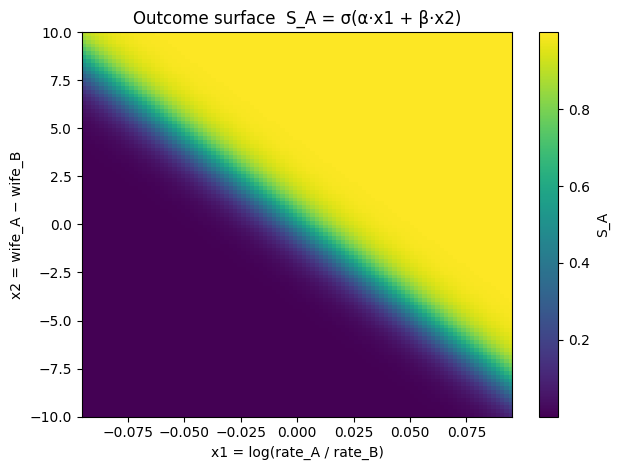

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# parameter grid
x1 = np.linspace(-np.log(1.1), np.log(1.1), 100)   # log(rate_A / rate_B)
x2 = np.linspace(-10, 10, 100)       # wife_A - wife_B
X1, X2 = np.meshgrid(x1, x2)

alpha = 110.0
beta = 1.25

Z = 1.0 / (1.0 + np.exp(-(alpha * X1 + beta * X2)))

plt.figure()
plt.imshow(Z, extent=[x1.min(), x1.max(), x2.min(), x2.max()],
           origin="lower", aspect="auto")
plt.colorbar(label="S_A")
plt.title("Outcome surface  S_A = σ(α·x1 + β·x2)")
plt.xlabel("x1 = log(rate_A / rate_B)")
plt.ylabel("x2 = wife_A − wife_B")
plt.tight_layout()


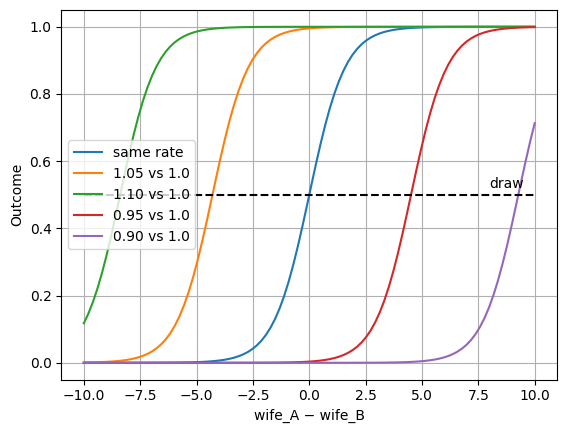

In [9]:

plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1) + beta * np.linspace(-10,10,100)))),label="same rate")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1.05) + beta * np.linspace(-10,10,100)))),label="1.05 vs 1.0")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1.1) + beta * np.linspace(-10,10,100)))),label="1.10 vs 1.0")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(0.95) + beta * np.linspace(-10,10,100)))),label="0.95 vs 1.0")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(0.9) + beta * np.linspace(-10,10,100)))),label="0.90 vs 1.0")
plt.plot([-10,10],[0.5,0.5],"--",c="black")
plt.text(8,0.52,"draw")
plt.legend()
plt.xlabel("wife_A − wife_B")
plt.ylabel("Outcome")
plt.grid()

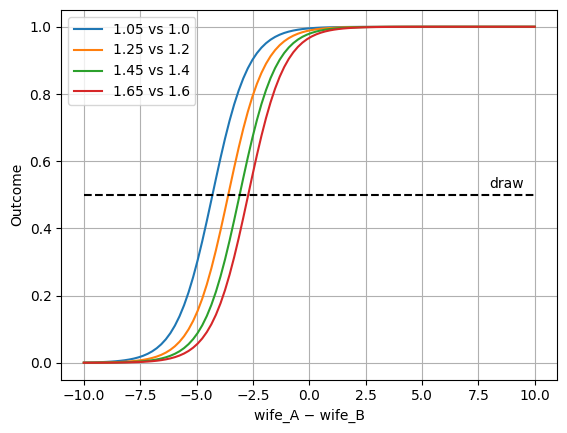

In [10]:

plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1.05) + beta * np.linspace(-10,10,100)))),label="1.05 vs 1.0")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1.25/1.2) + beta * np.linspace(-10,10,100)))),label="1.25 vs 1.2")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1.45/1.4) + beta * np.linspace(-10,10,100)))),label="1.45 vs 1.4")
plt.plot(np.linspace(-10,10,100),1.0 / (1.0 + np.exp(-(alpha*np.log(1.65/1.6) + beta * np.linspace(-10,10,100)))),label="1.65 vs 1.6")
plt.plot([-10,10],[0.5,0.5],"--",c="black")
plt.text(8,0.52,"draw")
plt.legend()
plt.xlabel("wife_A − wife_B")
plt.ylabel("Outcome")
plt.grid()

---

Wife linearization

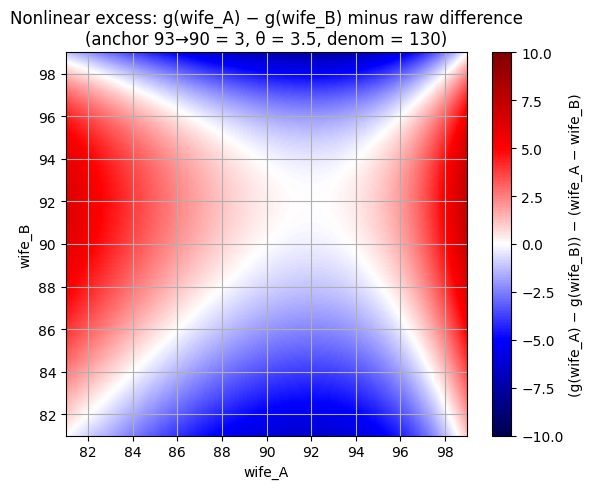

In [38]:
# Range of wife scores for both players
wife_range = np.linspace(80, 99, 200)
X, Y = np.meshgrid(wife_range, wife_range)

theta = 7.5
denom = 130.0

def h(w):
    p = np.clip(w / denom, 1e-6, 1 - 1e-6)
    return (-np.log1p(-p)) ** theta

c = 3.0 / (h(93.0) - h(90.0))  
def g(w):
    return c * h(w)

Z = (g(X) - g(Y)) - (X - Y)

plt.figure(figsize=(6, 5))
im = plt.imshow(Z, extent=[81, 99, 81, 99], origin="lower", aspect="auto", cmap="seismic", vmin=-10, vmax=10)
plt.colorbar(im, label="(g(wife_A) − g(wife_B)) − (wife_A − wife_B)")
plt.title("Nonlinear excess: g(wife_A) − g(wife_B) minus raw difference\n(anchor 93→90 = 3, θ = 3.5, denom = 130)")
plt.xlabel("wife_A")
plt.ylabel("wife_B")
plt.tight_layout()
plt.grid()
plt.show()


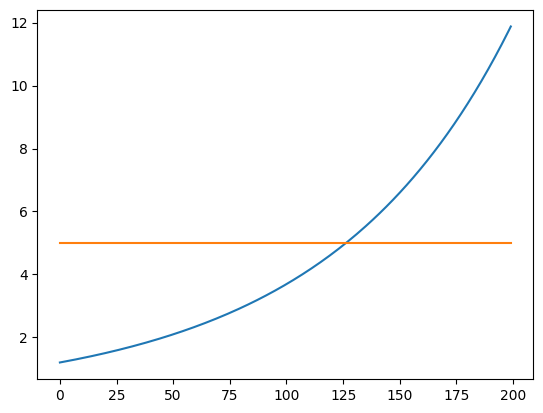

In [45]:
X = np.linspace(85, 99, 200)
Y = X - 5

plt.plot((g(X) - g(Y)))

plt.plot(((X) - (Y)))

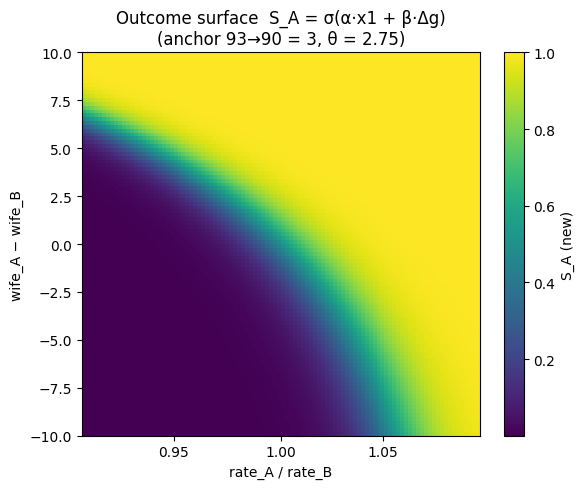

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter grid
x1 = np.linspace(-np.log(1.1), np.log(1.1), 100)   # log(rate_A / rate_B)
x2 = np.linspace(-10, 10, 100)                     # wife_A - wife_B
X1, X2 = np.meshgrid(x1, x2)

# Hyper‑parameters
alpha = 90.0
beta  = 1.0
theta = 5.5
denom = 130.0

def h(w):
    p = np.clip(w / denom, 1e-6, 1 - 1e-6)
    return (-np.log1p(-p)) ** theta

c = 3.0 / (h(93.0) - h(90.0))
def g(w):
    return c * h(w)

wB = 90.0
wA = wB + X2
Z = 1.0 / (1.0 + np.exp(-(alpha * X1 + beta * (g(wA) - g(wB)))))

# x-axis ticks in terms of original rate ratio
rate_ratios = [0.95, 1.0, 1.05]
x_tick_positions = np.log(rate_ratios)
x_tick_labels = [f"{r:.2f}" for r in rate_ratios]

plt.figure(figsize=(6, 5))
plt.imshow(Z, extent=[x1.min(), x1.max(), x2.min(), x2.max()],
           origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(label="S_A (new)")
plt.title("Outcome surface  S_A = σ(α·x1 + β·Δg)\n(anchor 93→90 = 3, θ = 2.75)")
plt.xlabel("rate_A / rate_B")
plt.ylabel("wife_A − wife_B")
plt.xticks(x_tick_positions, x_tick_labels)
plt.tight_layout()
plt.show()
